In [2]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))
%load_ext autoreload
%autoreload 2

In [3]:
import cv2
import numpy as np
import torch
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

from huggingface_hub import snapshot_download
from cosmos_tokenizer.image_lib import ImageTokenizer

from nanofm.data.multimodal.simple_multimodal_dataset import SimpleMultimodalDataset
from nanofm.data.multimodal.masking import SimpleMultimodalMasking

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

snapshot_download(
    repo_id='nvidia/Cosmos-0.1-Tokenizer-DI16x16', 
    local_dir='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16'
)
image_tokenizer = ImageTokenizer(
    checkpoint_enc='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16/encoder.jit',
    checkpoint_dec='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16/decoder.jit',
).to(device)

/work/com-304/new_environment/anaconda3/envs/nanofm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

decoder.jit:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

encoder.jit:   0%|          | 0.00/70.2M [00:00<?, ?B/s]

autoencoder.jit:   0%|          | 0.00/169M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

model_config.yaml:   0%|          | 0.00/92.0 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [14]:
from fourm.vq.vqvae import DiVAE

tok_edge_fourm = DiVAE.from_pretrained('EPFL-VILAB/4M_tokenizers_edge_8k_224-512').eval().to(device)


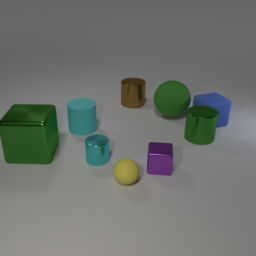

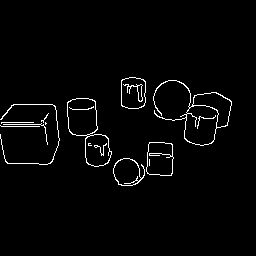

(256, 256)

In [93]:
crop_settings_0 = np.load("/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy")
rgb_img = Image.open("/scratch/tmaillar/rgb/train/point_30_view_0_domain_rgb.png").convert("RGB")
aug_idx = 1
x1, y1, x2, y2, flip = crop_settings_0[aug_idx]
top, left, h, w = y1, x1, (y2 - y1), (x2 - x1)
cropped = TF.crop(rgb_img, top, left, h, w)
resized = cropped.resize((256, 256), resample=Image.BILINEAR)
if flip:
    resized = TF.hflip(resized)

resized.show()
resized_numpy = np.array(resized)

LOW = 50
HIGH = 150
edges = cv2.Canny(resized_numpy, LOW, HIGH)

Image.fromarray(edges).show()
edges.shape
# rgb_img_tensor = TF.to_tensor(resized).to(device)

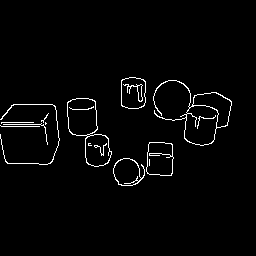

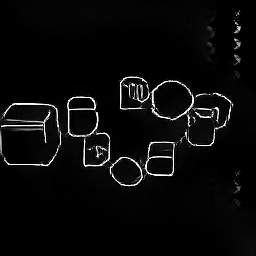

In [94]:
# stack 3 times for Cosmos tokenizer
edges_rgb = np.stack([edges, edges, edges], axis=-1)
Image.fromarray(edges_rgb).show()
# to tensor 
edges_tensor = TF.to_tensor(edges_rgb).to(device).unsqueeze(0) * 2 - 1

tokens, _ = image_tokenizer.encode(edges_tensor)
reconst = image_tokenizer.decode(tokens)

reconst_gray = reconst[0].mean(dim=0).clamp(-1, 1).float().cpu()
reconst_display = ((reconst_gray + 1) / 2 * 255).to(torch.uint8).numpy()
Image.fromarray(reconst_display).show()

# reconst = (reconst[0].clamp(-1,1).float().cpu() + 1) / 2
# TF.to_pil_image(reconst).show()

In [95]:
TARGET_SIZE = 256

edges_4m = cv2.resize(edges, (TARGET_SIZE, TARGET_SIZE))
edges_4m = edges_4m.astype(np.float32) / 255.0
edges_4m = edges_4m * 2.0 - 1.0

edges_4m = torch.tensor(edges_4m).unsqueeze(0).unsqueeze(0).to(device)
edges_4m.shape


torch.Size([1, 1, 256, 256])

In [96]:
with torch.no_grad():
    fourm_edge_tokens = tok_edge_fourm.tokenize(edges_4m)
fourm_edge_tokens.shape

torch.Size([1, 16, 16])

In [97]:
with torch.no_grad():
    reconst_4m = tok_edge_fourm.decode_tokens(fourm_edge_tokens, image_size=TARGET_SIZE)
reconst_4m.shape

torch.Size([1, 1, 256, 256])

In [98]:
img = reconst_4m[0]

img = img.squeeze(0)

img = img.clamp(-1, 1)
img = (img + 1) / 2
img_np = img.cpu().numpy()

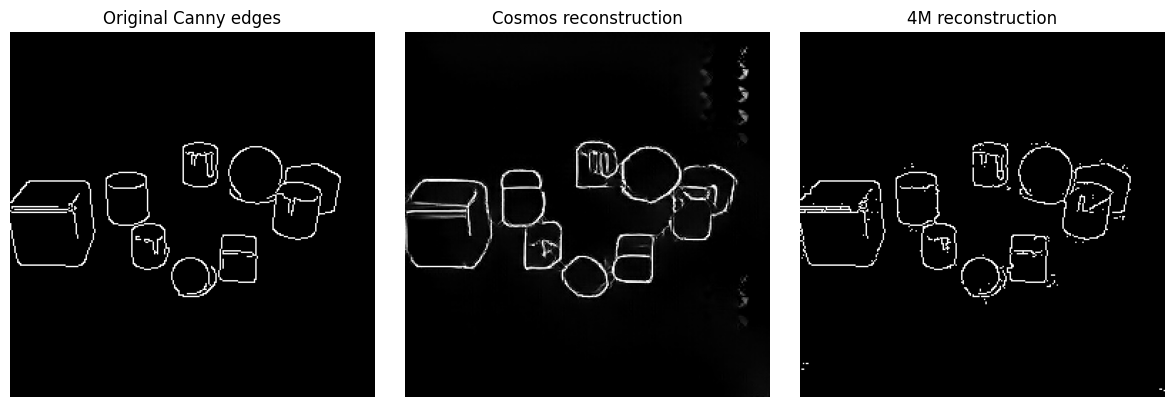

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Original Canny edges")
axes[0].axis("off")

axes[1].imshow(reconst_display, cmap="gray")
axes[1].set_title("Cosmos reconstruction")
axes[1].axis("off")

axes[2].imshow(img_np, cmap="gray")
axes[2].set_title("4M reconstruction")
axes[2].axis("off")

plt.tight_layout()
plt.show()